# Tensorflow 실습
##  Tensorflow 기초
* tensorflow import

In [10]:
import tensorflow as tf
tf.__version__

'2.20.0'

* Tensor Object

In [11]:
# tf.Tensor 객체
# tf.constant() 함수로 생성
# 값의 변경 불가능

a = tf.constant(1)
b = tf.constant([[1,2], [3,4]])
print(a, b)

tf.Tensor(1, shape=(), dtype=int32) tf.Tensor(
[[1 2]
 [3 4]], shape=(2, 2), dtype=int32)


* Variable

In [12]:
# 값 변경이 가능한 Tensor Object
# tf.Variable()생성
# assign(), assign_sub()등 값 할당 함수 지원

v = tf.Variable(3)
print(v)
v.assign(10)
print(v)

<tf.Variable 'Variable:0' shape=() dtype=int32, numpy=3>
<tf.Variable 'Variable:0' shape=() dtype=int32, numpy=10>


* 자동 미분

tf.GradientTape([persistent=True]) : 생성

gradient() : 미분계산

컨텍스트 내의 모든 정방향(Forward-pass)연산을 Tape에 기록

역방향 자동 미분연산(Reverse mode differentiation)후 폐기

컨텍스트 내의 중간 계산 값도 미분 가능

-> backpropogation 자동 적용


In [13]:
x = tf.Variable(3.0)
with tf.GradientTape(persistent=True) as tape:
    y = x ** 2# y = x^2 , y = 3^2, y = 9
    print("y: ", y.numpy())
    z = 2 * y # z = 2* (x^2), z = 2*y, z = 2*9, z = 18
    print("z:", z.numpy())
dy_dx = tape.gradient(y, x)  # 6.0 (2*3 at x =3)
dz_dx = tape.gradient(z, x)  # 12.0 (4*3 at x = 3)
print("dy_dx:", dy_dx.numpy())
print("dz_dx:", dz_dx.numpy())

y:  9.0
z: 18.0
dy_dx: 6.0
dz_dx: 12.0


## 선형회귀 실습

* 데이타 생성

(50,) (50,)


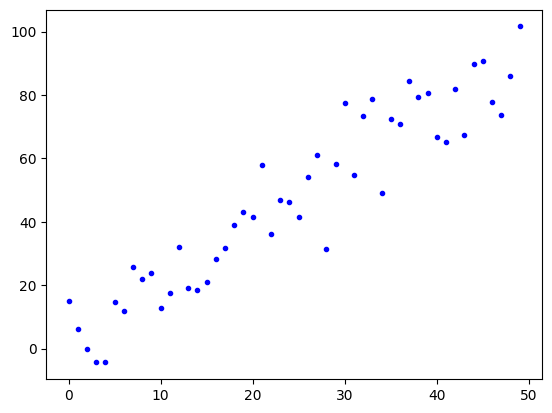

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

tf.random.set_seed(0)
np.random.seed(0)

m = 50
X = tf.constant(range(m), tf.float32)
y = X * 2
y = y + tf.random.normal((50,)) *10 # 2X + 10eps
print(X.shape, y.shape)
plt.plot(X,y,'b.')

* 회귀식 학습

0, cost:667.541748046875, W:1.066880226135254
20, cost:91.10315704345703, W:1.8868070840835571
40, cost:90.6057357788086, W:1.9108930826187134
60, cost:90.60529327392578, W:1.9116005897521973
80, cost:90.60531616210938, W:1.911621332168579
final, cost:90.60531616210938, W:1.9116216897964478


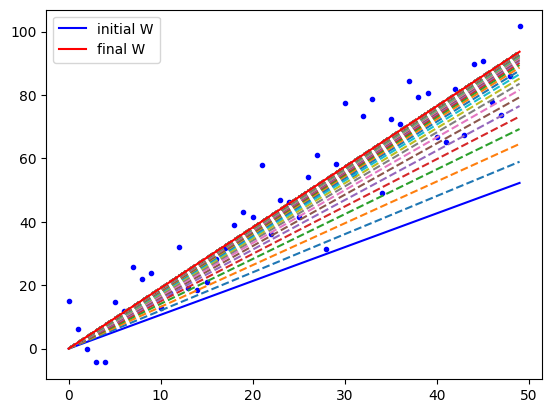

In [15]:
plt.plot(X,y,'b.')

W = tf.Variable(tf.random.normal(()))
plt.plot(X, X*W, 'b', label='initial W')

lr = 0.0001
for i in range(100):
    with tf.GradientTape() as tape:
        h = W*X
        cost = tf.reduce_mean((h-y)**2) # MSE구현
        #cost = tf.keras.losses.MSE(y, h)
    if i %20 ==0:
        print(f'{i}, cost:{cost.numpy()}, W:{W.numpy()}')
    dw = tape.gradient(cost, W)
    W.assign( W - dw*lr)
    plt.plot(X, W*X, '--')

plt.plot(X, W*X, 'r-', label='final W')
print(f'final, cost:{cost.numpy()}, W:{W.numpy()}')
plt.legend()

* Optimizer
  * SGD Optimizer 적용
  
  tf.keras.optimizers.Optimizers(learning_rate)

  가중치 업데이트 자동화도구
  SGD : 가장 기초적인 옵티마이저
  Adam : 1차 2차 모멘트 적응적 추정
  RMSprop : 일반 운동 모멘텀

0, cost:11253.40625, W:-1.804128646850586
20, cost:100.23806762695312, W:1.80246901512146
40, cost:90.61361694335938, W:1.90841543674469
60, cost:90.60531616210938, W:1.9115277528762817
80, cost:90.60530090332031, W:1.9116191864013672
final, cost:90.60531616210938, W:1.9116216897964478


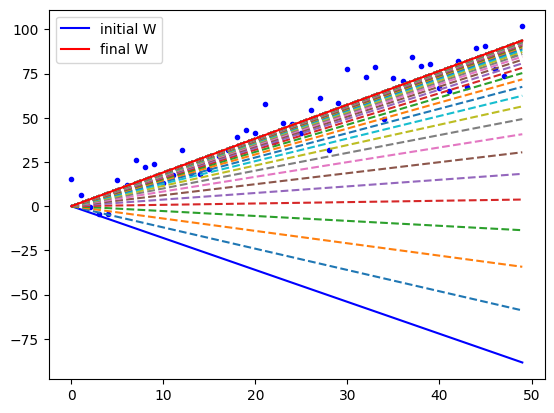

In [16]:
plt.plot(X,y,'b.')

W = tf.Variable(tf.random.normal(()))
plt.plot(X, X*W, 'b', label='initial W')

lr = 0.0001
optimizer = tf.keras.optimizers.SGD(lr)
for i in range(100):
    with tf.GradientTape() as tape:
        h = W*X
        cost = tf.keras.losses.MSE(y, h)
    if i %20 ==0:
        print(f'{i}, cost:{cost.numpy()}, W:{W.numpy()}')
    dw = tape.gradient(cost, W)
    # W.assign( W - dw*lr) 대신 SGD optimizer 적용
    optimizer.apply_gradients(zip([dw], [W]))
    plt.plot(X, W*X, '--')

plt.plot(X, W*X, 'r-', label='final W')
print(f'final, cost:{cost.numpy()}, W:{W.numpy()}')
plt.legend()

## XOR 문제 해결

In [17]:
import tensorflow as tf
import numpy as np
tf.random.set_seed(777)
np.random.seed(0)

X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=np.float32)
y = np.array([[0], [1], [1], [0]], dtype=np.float32)
W1 = tf.Variable(tf.random.normal([2, 2]))
b1 = tf.Variable(tf.random.normal([2]))
W2 = tf.Variable(tf.random.normal([2, 1]))
b2 = tf.Variable(tf.random.normal([1]))

opt = tf.keras.optimizers.SGD(0.1)
ephochs = 10000
for step in range(ephochs):
    with tf.GradientTape() as tape:
        L1 = tf.sigmoid(tf.matmul(X, W1) + b1)
        h = tf.sigmoid(tf.matmul(L1, W2) + b2)
        cost = tf.reduce_mean(tf.losses.MSE(y, h))
        d_W1, d_b1, d_W2, d_b2 = tape.gradient(cost, [W1, b1, W2, b2] )
        opt.apply_gradients(zip([d_W1, d_b1, d_W2, d_b2], [W1, b1, W2, b2]))
        if step % 500 == 0:
            print(f"step:{step},\t cost:{cost}")

pred = tf.math.round(h) # 0,1 두개의 값만 갖기위해 반올림
acc = np.mean(pred == y)
print(f"Hypothesis:{h} \nPredicted:{pred} \nAccuracy:{acc*100}%")
print(f"w1:{W1.numpy()} b1:{b1.numpy()} w2:{W2.numpy()} b2{b2.numpy()}")

step:0,	 cost:0.36900365352630615
step:500,	 cost:0.2501450479030609
step:1000,	 cost:0.25006455183029175
step:1500,	 cost:0.24999824166297913
step:2000,	 cost:0.24992811679840088
step:2500,	 cost:0.24983808398246765
step:3000,	 cost:0.24970725178718567
step:3500,	 cost:0.24950240552425385
step:4000,	 cost:0.2491636574268341
step:4500,	 cost:0.24857541918754578
step:5000,	 cost:0.24749943614006042
step:5500,	 cost:0.24542474746704102
step:6000,	 cost:0.2412615567445755
step:6500,	 cost:0.23294663429260254
step:7000,	 cost:0.21761807799339294
step:7500,	 cost:0.192561537027359
step:8000,	 cost:0.1550426036119461
step:8500,	 cost:0.10876106470823288
step:9000,	 cost:0.06994733214378357
step:9500,	 cost:0.04580104351043701
Hypothesis:[[0.18162666]
 [0.78304034]
 [0.8482494 ]
 [0.15713167]] 
Predicted:[[0.]
 [1.]
 [1.]
 [0.]] 
Accuracy:100.0%
w1:[[ 4.1951118  3.653032 ]
 [-4.297973  -3.404751 ]] b1:[-2.543043   1.6556258] w2:[[ 5.137868 ]
 [-4.5679903]] b2[1.9552189]


# Keras 응용 실습

TensorFlow의 공식 high-level API

#### Input



```
tf.keras.input
```



keras 텐서 객체, Tensorflow Tensor를 추상화

모델의 입력으로 사용



#### Layer

(1) Neural Network의 하나의 Layer를 추상화

```
tf.keras.layer.Layer(trainable, name, dtype, dynamic)
```

기반 클래스, 직접 사용불가

(2) 가장 일반적인 DNN의 완전 연결층



```
tf.keras.layers.Dense(units,activation,use_bias, kernel_initalizer, bias_initializer)
```

units: 필수, 출력 shape, 샘플 축 생략

input_shape : 첫번째 층인 경우 사용

ex1. Dense(32, input_shape(784,)) : 입력 nx784, 출력 32
ex2. Dense(10) : 입력층 생략, 이전 층의 출력의 갯수로 자동 지정

(3) 순환 네트워크, 시계열이나 시퀀스


```
tf.keras.layers.RNN, LSTM, GRU
```


(4) 이미지 특징 추출 및 분류



```
tf.keras.layers.Conv2D
```

(5) Dropout


```
tf.keras.layers.Dropout(rate,...)
```



#### keras Model

Layer를 그룹화해서 훈련과 예측 기능을 하는 객체



```
tf.keras.Model(input, output)
```

trainable_variables : 학습할 변수 목록

1. compile(optimizer, loss, metrics,...)
: 훈련을 위한 모델 설정

- optimizer : tf.keras.optimizers에 있는 객체 또는 이름(str)
- loss : tf.keras.losses내의 객체 또는 이름(str)
- metric : 훈련과 테스트 과정에서 평가할 지표

2. history = fit(x,y,batch_size, epochs, verbose, callbacks, validation_split, validation_data..)

- 모델 학습
- history : 학습 동안의 loss 등의 메트릭 기록
  - history : dictionary, 기록 항목 별

3. evaluate(x,y ...)

- 테스트 결과 반환

4. summary()

- network의 층과 파라미터 갯수 출력

5. predict(x, ...)

- 예측 결과

6. save(filepath, ...)

- 모델 파일 저장
- tf.models.load_model(filepath) : 모델 복원


#### keras sequential

Layer Stack을 만드는 쉬운 방법



```
tf.keras.Sequential(layers)
```

layers인자에 layer 넣는 방법
1. layer : layer 객체를 갖는 리스트로 만들어서 한번에 전달
2. add(layer) : 하나씩 계층 추가

prediction

- call(x) 사용.but, predict()함수가 더 자주 사용됨


## 회귀문제, 보스턴 주택가격
* 데이타 불러오기

In [18]:
from tensorflow.keras.datasets import boston_housing
(X_train, y_train), (X_test, y_test) = boston_housing.load_data()
print(X_train.shape, X_test.shape)
print(X_train[0])
print(y_train[0])

(404, 13) (102, 13)
[  1.23247   0.        8.14      0.        0.538     6.142    91.7
   3.9769    4.      307.       21.      396.9      18.72   ]
15.2


* 정규화 전처리

In [19]:
mean = X_train.mean(axis=0)
X_train -= mean
std = X_train.std(axis=0)
X_train /= std

X_test -=mean
X_test /=std

print(X_train[0])
print(X_test[0])

[-0.27224633 -0.48361547 -0.43576161 -0.25683275 -0.1652266  -0.1764426
  0.81306188  0.1166983  -0.62624905 -0.59517003  1.14850044  0.44807713
  0.8252202 ]
[ 1.55369355 -0.48361547  1.0283258  -0.25683275  1.03838067  0.23545815
  1.11048828 -0.93976936  1.67588577  1.5652875   0.78447637 -3.48459553
  2.25092074]


* 모델 정의

In [22]:
# 리스트로 만들어서 한번에 전달, 회귀문제이므로 마지막 레이어의 활성화함수는 없음

model = tf.keras.models.Sequential([
  tf.keras.layers.Dense(52, activation='relu', input_shape=(13,)),
  tf.keras.layers.Dense(39, activation='relu'),
  tf.keras.layers.Dense(26, activation='relu'),
  tf.keras.layers.Dense(1)
])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 52)             │           728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 39)             │         2,067 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 26)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,862 (15.09 KB)

 Trainable params: 3,862 (15.09 KB)

 Non-trainable params: 0 (0.00 B)

* 모델 학습

In [23]:
history = model.fit(X_train, y_train,
                    epochs=100, batch_size=32,
                    validation_split=0.25) # 각 epoch마다 훈련이 되면 즉각적으로 테스트 할 수 있게 만든 validation_split, train data의 1/4만큼

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - loss: 538.2576 - mae: 21.4298 - val_loss: 662.8599 - val_mae: 23.6827
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 512.6773 - mae: 20.8072 - val_loss: 629.1049 - val_mae: 22.9591
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 475.6017 - mae: 19.8722 - val_loss: 576.2842 - val_mae: 21.7740
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 418.0984 - mae: 18.3521 - val_loss: 494.1185 - val_mae: 19.8287
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 334.5430 - mae: 15.9465 - val_loss: 379.1088 - val_mae: 16.8116
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 232.3957 - mae: 12.7899 - val_loss: 247.1318 - val_mae: 12.9847
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 136.1152 - mae: 9.4653 - val_loss: 138.3792 - val_mae: 9.0150
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 77.7309 - mae: 6.8308 - val_loss: 91.8746 - val_mae: 7.6343
Epoch 9/100
10

* 학습 결과 시각화


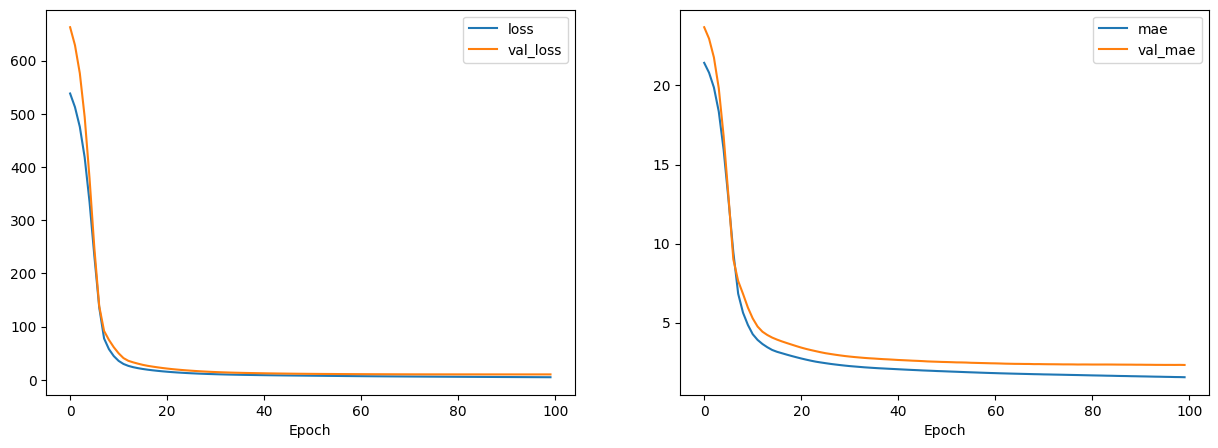

In [24]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['mae'], label='mae')
plt.plot(history.history['val_mae'], label='val_mae')
plt.xlabel('Epoch')
plt.legend()


## 분류 문제 - MNIST 손글씨 인식

* 데이터 불러오기

<class 'tuple'> 2
(60000, 28, 28) (10000,)
(10000, 28, 28) (10000,)


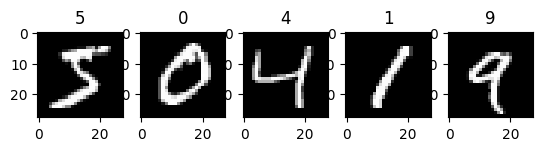

In [37]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

mnist = tf.keras.datasets.mnist.load_data() #load_data()를 사용해서 데이터 로드
print(type(mnist), len(mnist))

(X_train, y_train), (X_test, y_test) = mnist
print(X_train.shape, y_test.shape)
print(X_test.shape, y_test.shape)

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(y_train[i])


* 데이터 정규화

In [38]:
# 픽셀 값 범위 : 0~255까지여서 255로 나누면 가장 큰 픽셀값은 255/255 = 1이 됨.

(X_train, X_test) = (np.float32(X_train)/255, np.float32(X_test)/255)
n_input = 28*28
(X_train, X_test) = (X_train.reshape(-1, n_input), X_test.reshape(-1, n_input))

* 모델 정의

In [39]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(300, activation='relu', input_shape=(28*28,)),
    tf.keras.layers.Dense(100, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')]) # 다항분류 활성화함수 softmax
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_25 (Dense)                │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

* 모델 학습

In [40]:

import numpy as np

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train,
    batch_size=100,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
480/480 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9183 - loss: 0.2871 - val_accuracy: 0.9620 - val_loss: 0.1330
Epoch 2/10
480/480 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9675 - loss: 0.1084 - val_accuracy: 0.9701 - val_loss: 0.1024
Epoch 3/10
480/480 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9800 - loss: 0.0673 - val_accuracy: 0.9712 - val_loss: 0.0931
Epoch 4/10
480/480 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9878 - loss: 0.0436 - val_accuracy: 0.9735 - val_loss: 0.0881
Epoch 5/10
480/480 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9923 - loss: 0.0291 - val_accuracy: 0.9761 - val_loss: 0.0822
Epoch 6/10
480/480 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9941 - loss: 0.0220 - val_accuracy: 0.9771 - val_loss: 0.0902
Epoch 7/10
480/480 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9939 - loss: 0.0206 - val_accuracy: 0.9758 - val_loss: 0.1021
Epoch 8/10
480/480 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9943 - loss: 0.0183 - val_accuracy: 

* 학습 결과 시각화

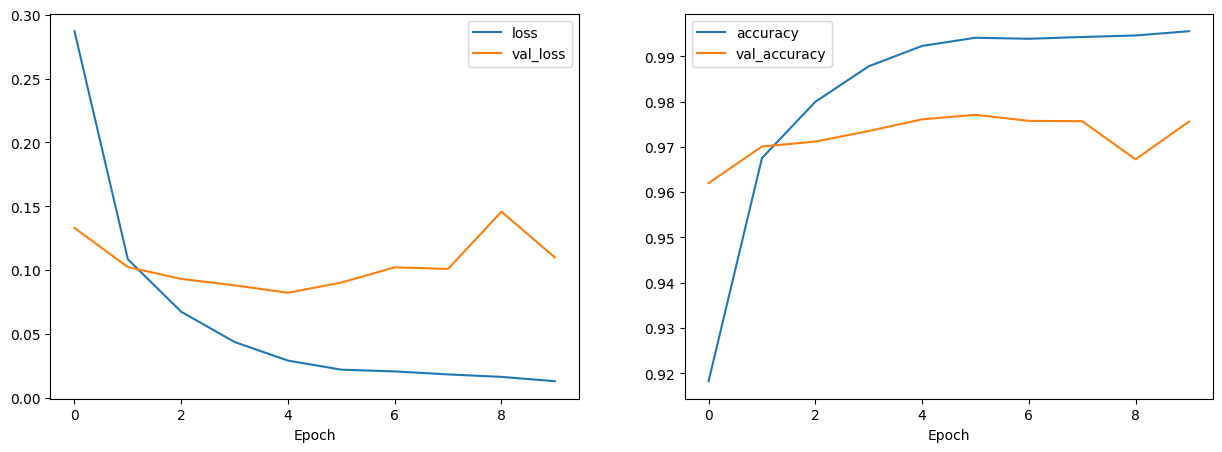

In [41]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.legend()

* 모델 저장과 복원

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9747 - loss: 0.1040


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
loaded model accuracy: 0.9747
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_7
Received: inputs=('Tensor(shape=(5, 784))',)
  warnings.warn(msg)


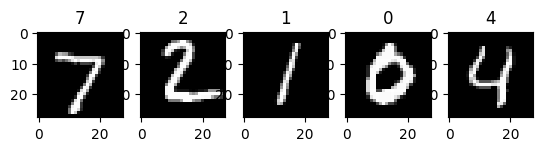

In [42]:
model_path = 'mnist.h5' # 저장할때 확장자 h5
model.evaluate(X_test, y_test)
model.save(model_path)

model2 = tf.keras.models.load_model(model_path)
acc = np.mean(np.argmax(model2.predict(X_test), axis=1) == y_test)
print(f"loaded model accuracy: {acc}")
pred = model2.predict([X_test[:5]])
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap="gray")
    plt.title(np.argmax(pred[i]))